# Classification Evaluation
### `! git clone https://github.com/ds4e/model_selection`

## Evaluating a Classifier
For regression, we have specific objectives to target and evaluate:

- SSE/MSE/RMSE: The weighted distance of our predictions to the truth
- $R^2$: The fraction of variance explained by the model, $ 1- SSE_{model}/SSE_{mean}$
- Log Likelihood/Cross Entropy: The distance from our predicted distribution to the observed/true one

For classification, we start from the confusion matrix: Cross tabulate predicted and actual

- This is more nuanced, in many ways
- This is more difficult to evaluate

Today we'll look at a variety of tools to ask, "Is this classifier doing well, or poorly?"

## Road Map
1. Building on the Confusion Matrix
2. ROC Curves and AUC: Varying the Threshold
3. Calibration

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 1. Building on the Confusion Matrix

## Example Data
- File: `./data/diabetes-dataset.csv`
- Each row is a patient and the target `Outcome` is whether the patient has diabetes
- This is a nice example dataset because:
    - the outcome is binary
    - the predictors are all numeric
    - all of our methods apply without squandering time on data cleaning/excessive feature engineering (kNN, linear probability model, logistic regression, classifier tree, random forest )

In [2]:
df = pd.read_csv("./data/diabetes-dataset.csv")
print(df["Outcome"].describe())
df.head()

count    2000.000000
mean        0.342000
std         0.474498
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: Outcome, dtype: float64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


## Hard vs Soft Classification
Remember, underneath all hard classification is soft classification:

- For kNN and classifier trees, we figure out the distribution of "votes", normalize, and pick the most likely category
- For logistic regression, we assign 0 if $\hat{p}_1 < .5$ and 1 otherwise
- For random forest, we average the results of all of the trees, then take the most likely category

When we make the hard classification, we lose some information, but this can be justified depending on the application at hand

## Exercise:
- Load the diabetes data, make an 80/20 train/test split
- For each of { 20-NN, logistic regression, classification tree with `min_samples_leaf=30`, random forest classifier  }, fit a model and predict values on the test set
- Save your predictions for each kind of model and your test values; we'll use these the rest of class

In [3]:
## Set up data for modeling

y = df["Outcome"]
X = df.drop(columns="Outcome")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=10
)

std = lambda x: (x - x.mean()) / x.std()
minmax = lambda x: (x - x.min()) / (x.max() - x.min())

X_train_std = X_train.apply(std)
X_test_std = X_test.apply(std)

X_train_mm = X_train.apply(minmax)
X_test_mm = X_test.apply(minmax)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_logit = poly.fit_transform(X_train_std)
X_test_logit = poly.transform(X_test_std)

In [4]:
## Fit models and get predicted probabilities

knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(X_train_mm, y_train)
pr_knn = knn.predict_proba(X_test_mm)[:,1]

logit = LogisticRegressionCV(
    Cs=np.logspace(-3, 2, 12),
    cv=5,
    penalty="l2",
    scoring="roc_auc",
    solver="lbfgs",
    max_iter=5000,
    random_state=100,
)
logit.fit(X_train_logit, y_train)
pr_logit = logit.predict_proba(X_test_logit)[:,1]

tree = DecisionTreeClassifier(random_state=100, min_samples_leaf=30)
tree.fit(X_train, y_train)
pr_tree = tree.predict_proba(X_test)[:,1]

rf = RandomForestClassifier(random_state=100)
rf.fit(X_train, y_train)
pr_rf = rf.predict_proba(X_test)[:,1]

/home/trj/miniconda3/envs/hmm/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/home/trj/miniconda3/envs/hmm/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/home/trj/miniconda3/envs/hmm/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_leg

In [5]:
## Save results for later
pr_all = pd.DataFrame({
    "y_test": y_test.reset_index(drop=True),
    "pr_knn": pr_knn,
    "pr_logit": pr_logit,
    "pr_tree": pr_tree,
    "pr_rf": pr_rf,
})

pr_all.head()

,y_test,pr_knn,pr_logit,pr_tree,pr_rf
0,1,0.35,0.512469,0.970588,0.83
1,1,0.65,0.647353,0.900000,0.87
2,1,0.30,0.237248,0.542857,0.77
3,0,0.00,0.000279,0.000000,0.01
4,0,0.15,0.192011,0.534884,0.16


## Converting to a Hard Classification
- From our df/matrix of predicted probabilties, we can convert to a hard classification easily with `clf = ( pr_all > .5 ).astype(int)`
- That's super helpful, let's make it a function:

``` python
def clf(lambda pr_mat, threshold) : 
    return (pr_mat > threshold).astype(int)
```

or as a lambda function:
``` python
clf = lambda pr_mat, threshold : (pr_mat > threshold).astype(int)
```

In [6]:
clf = lambda pr_mat, threshold : (pr_mat > threshold).astype(int)
clf(pr_all, .5).head()

,y_test,pr_knn,pr_logit,pr_tree,pr_rf
0,1,0,1,1,1
1,1,1,1,1,1
2,1,0,0,1,1
3,0,0,0,0,0
4,0,0,0,1,0


## The Confusion Matrix
- Pick a threshold, usually `0.5` but not necessarily
- Convert predicted probabilities into predicted classes
- Cross tabulate predictions against truth:

|  | Predicted 0 | Predicted 1 |
| :---: | :---: | :---: |
| Actual 0 | True Negative (TN) | False Positive (FP) |
| Actual 1 | False Negative (FN) | True Positive (TP) |

- We can use `from sklearn.metrics import confusion_matrix` to quickly make them
- Every common classification metric comes from these four counts

In [7]:
for col in pr_all.columns[1:]: # For each prediction column
    y_hard = clf(pr_all[col], .5) # Make hard classification
    cm = confusion_matrix(y_test, y_hard) # Confusion matrix
    print(f"Confusion matrix for {col}:\n") # Print...
    print(cm)
    print('\n')

Confusion matrix for pr_knn:

[[233  36]
 [ 45  86]]


Confusion matrix for pr_logit:

[[236  33]
 [ 44  87]]


Confusion matrix for pr_tree:

[[225  44]
 [ 37  94]]


Confusion matrix for pr_rf:

[[266   3]
 [  6 125]]




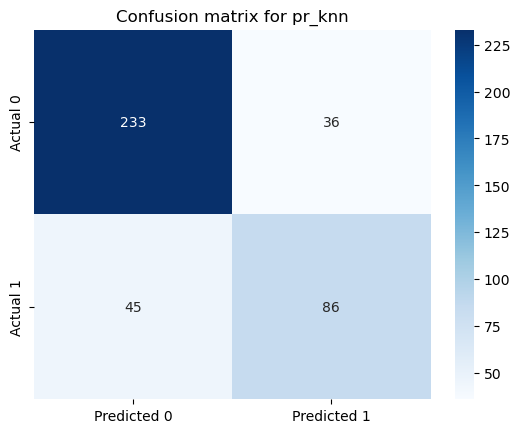

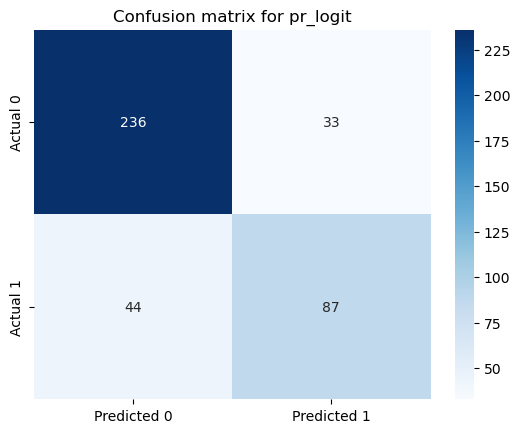

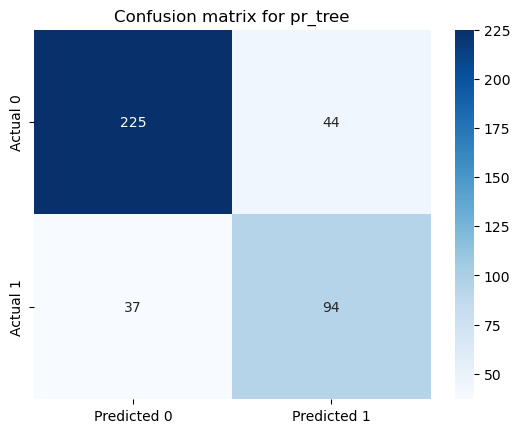

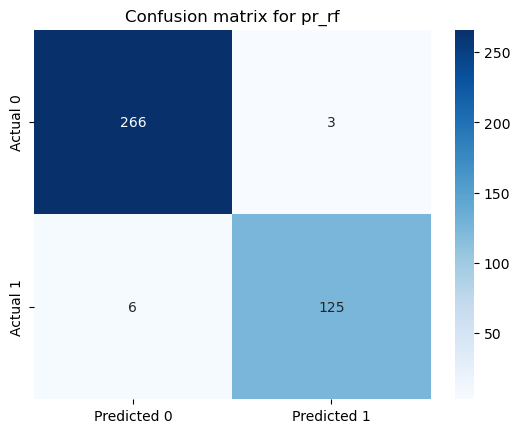

In [8]:
for col in pr_all.columns[1:]: # For each prediction column
    y_hard = clf(pr_all[col], .5) # Make hard classification
    cm = confusion_matrix(y_test, y_hard) # Confusion matrix
    cm_df = pd.DataFrame( # Turn cm into labelled data frame
        cm,
        index=["Actual 0", "Actual 1"],
        columns=["Predicted 0", "Predicted 1"],
    )
    sns.heatmap(cm_df, 
                annot=True, # Add count labels
                fmt='.0f', # No scientific notation
                cmap="Blues")
    plt.title(f"Confusion matrix for {col}" )
    plt.show()

## Accuracy
- Accuracy has been our main summary so far: the fraction of correct hard predictions:
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN} = \frac{TP + TN}{N}$$
- This is estimating something: The **unconditional probability that the prediction is correct**, $\widehat{pr}[\hat{y}=y]$
- Accuracy is useful, but it does not tell us *what kinds of mistakes* the model is making
- There are many, many other conditional probabilities to be estimated from the table

## Conditional Probability
- If we know something $B$ is true and $A$ is still uncertain, we can compute the conditional probability of $A$ given $B$ as
$$
\text{pr}[A|B] = \dfrac{\text{probability of $A$ and $B$ together}}{\text{probability of $B$}}
$$
- If we pick a row or column of the confusion matrix and then compute the proportion of successes or errors, we are estimating some dimension of the classifier's performance

## How many stats would a statistician stat if a statistician could stat stats?
- **Accuracy**: probability of being correct, $\widehat{pr}[\hat{y}=y]$

Conditional on truth:
- **Sensitivity** or **Recall**: given a true $y=1$, the probability we're correct, $\widehat{pr}[\hat{y}=1|y=1]$
- **Specificity**: given a true $y=0$, the probability we're correct, $\widehat{pr}[\hat{y}=0|y=0]$

Conditional on prediction:
- **Precision**: given that we predicted $\hat{y}=1$, the probability we're 
correct, $\widehat{pr}[y=1|\hat{y}=1]$
- **Negative Predictive Value**: given that we predicted $\hat{y}=0$, the probability we're correct, $\widehat{pr}[y=0|\hat{y}=0]$

Mistakes conditional on truth:
- **False Positive Rate**: Given the truth is $y=0$, the probability we predicted $\hat{y}=1$: $\widehat{pr}[\hat{y}=1|y=0] = 1 - \text{specificity}$
- **False Negative Rate**: Given the truth is $y=1$, the probability we predicted $\hat{y}=0$: $\widehat{pr}[\hat{y}=0|y=1] = 1 - \text{sensitivity}$

## Exercise
- Use the conditional probability formula and the defintions to write the performance stats in terms of $TN$, $TP$, $FN$, $FP$

## F1
- Those predicted probabilities are all great: They capture some feature of classifier performance, and they all deserve consideration
- There are two metrics that combine multiple stats into one number

The **F1** score is
$$
F1 = 2 \times \dfrac{Precision \times Recall}{Precision + Recall}
$$
This is the **harmonic mean** of precision and recall, attempting to consolidate those two dimensions of performance into one number


In [9]:
def metrics( pr_all, threshold = .5 ):
    clf_all = clf(pr_all,threshold) # Make hard predictions
    y_test = clf_all["y_test"] # Set aside true values

    calcs = []
    for col in clf_all.columns[1:]: # For each prediction column
        y_hard = clf_all[col] # Make hard classification
        cm = confusion_matrix(y_test, y_hard) # Confusion matrix
        tn, fp, fn, tp = cm.ravel() # get performance values
        calcs.append({ # Compute and append metrics
            "accuracy": (tp + tn) / len(y_test),
            "sensitivity": tp / (tp + fn),
            "specificity": tn / (tn + fp),
            "precision": tp / (tp + fp),
            "npv": tn / (tn + fn),
            "false_positive_rate": fp / (fp + tn),
            "f1": 2 * tp / (2 * tp + fp + fn),
        }
        )    
    return pd.DataFrame(calcs, index=clf_all.columns[1:]).round(3)
    
metrics(pr_all, .5)

,accuracy,sensitivity,specificity,precision,npv,false_positive_rate,f1
pr_knn,0.798,0.656,0.866,0.705,0.838,0.134,0.680
pr_logit,0.808,0.664,0.877,0.725,0.843,0.123,0.693
pr_tree,0.798,0.718,0.836,0.681,0.859,0.164,0.699
pr_rf,0.978,0.954,0.989,0.977,0.978,0.011,0.965


# 2. ROC and AUC: Varying the Threshold

## Comparing Several Models at the Same Threshold
- If we vary the threshold from $.5$, we discover that the models perform differently
- What's so special about .5, especially if we're predicting rare or likely events, where discrimation around .5 is somewhat irrelevant anyway?
- We can vary the threshold to probe model performance, leading to a **receiver operating characteristics curve** or ROC curve

## Threshold Choice Changes Classifier Performance
- Lowering it makes the model induces it to classify more cases as $\hat{y}=1$, while raising it makes the model classify more cases as $\hat{y}=0$
- That means sensitivity and specificity usually move in opposite directions
- Because of this, we often want to focus on sensitivity and specificity, as ways of thinking about true positive and false positive performance for the same model
- Imagine a scenario where we're trading off the problem of correctly predicting sick people versus over-predicting sick people

## ROC Logic
ROC stands for **Receiver Operating Characteristic**

To build a ROC curve we,

1. Fix the threshold at some value, and compute:
    - **True Positive Rate (TPR)** = sensitivity
    - **False Positive Rate (FPR)** = $1 -$ specificity
2. Cycle over all plausible threshold values, and plot the TPR and FPR

- Then plot TPR against FPR as the threshold moves from strict to loose
- This lets us compare classifiers without committing to one threshold too early
- Scikit provides tools to do this, namely `roc_curve(y_hat, y_test)`

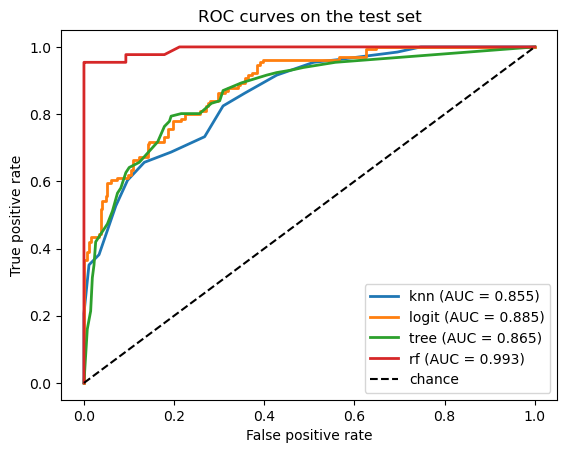

In [10]:
roc_rows = []

for col in pr_all.columns[1:]:
    fpr, tpr, _ = roc_curve(pr_all["y_test"], pr_all[col])
    auc_value = roc_auc_score(pr_all["y_test"], pr_all[col])
    label = col.replace("pr_", "")
    roc_rows.append(pd.Series({"model": label, "auc": auc_value}))
    plt.plot(fpr, tpr, linewidth=2, label=f"{label} (AUC = {auc_value:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="black", label="chance")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves on the test set")
plt.legend()
plt.show()


## ROC Curves
- So the random forest crushes it with these data: As promised, it's a wildly powerful data science tool
- Notice, RF performs well, and it is the most "to the upper left" of the classifiers; the other classifiers perform similarly, and group together somewhat
- The best classifiers will have high TPR as the threshold for FPR sweeps from 0 to 1 (by varying the threshold, we must increase the number of false positives, and the trade-off is a better TPR)
- So the models are somewhat ranked as RF > Logit > Tree > knn
- Is there a way to formalize that ranking with one number?

## Interpreting AUC
- **AUC** means **Area Under the Curve**
- Bigger is better:
    - `0.50` means roughly no discrimination
    - `1.00` means perfect discrimination
- A useful intuition:
    - AUC is the probability that a randomly chosen positive case gets a higher score than a randomly chosen negative case
- So AUC is mainly about **ranking quality**

In [11]:
auc_table = pd.DataFrame(roc_rows).set_index("model").round(3)
auc_table

,auc
model,
knn,0.855
logit,0.885
tree,0.865
rf,0.993


## How ROC Connects Back to the Confusion Matrix
- A single point on the ROC curve corresponds to one threshold
- Changing the threshold changes the confusion matrix
- So the ROC curve is really a picture of *all possible confusion-matrix tradeoffs at once*

## ROC and AUC
- ROC and AUC give a much more nuanced portrait of how a classifier "works" by looking at the TPR and FPR together
- This gives us a framework for evaluating performance in a more nuanced way, without simply staring at the confusion matrix

# 3. Calibration

## An Unsatisfying Plot
- For a classifier, we have all plotted the predicted probability against the true outcome, and gotten a plot like the following one
- Why is it... not helpful?
- Calibration is roughly the fix for this bad plot, to help understand model performance with respect to the truth

In [12]:
plot_df = pr_all.melt(
    id_vars="y_test",
    var_name="model",
    value_name="predicted_risk"
)
plot_df["model"] = plot_df["model"].str.replace("pr_", "", regex=False)

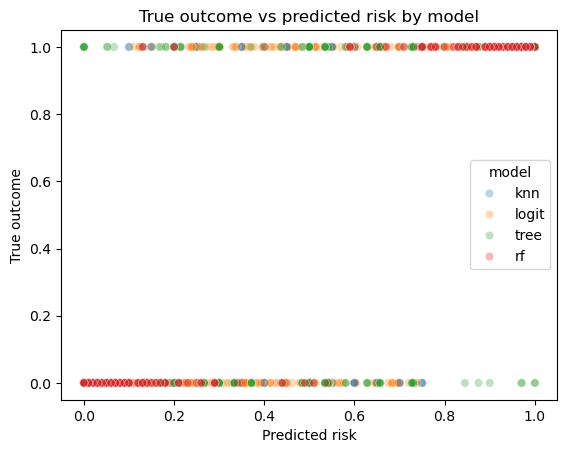

In [13]:
sns.scatterplot(
    data=plot_df,
    x="predicted_risk",
    y="y_test",
    hue="model",
    alpha=0.3,
)
plt.xlabel("Predicted risk")
plt.ylabel("True outcome")
plt.title("True outcome vs predicted risk by model")
plt.show()


## What Is Calibration?
- **Calibration**: When a model says "this case has probability `0.70` of being positive," does that number mean what it says?
- In a perfectly calibrated model:
    - cases predicted around `0.20` are positive about 20% of the time
    - cases predicted around `0.80` are positive about 80% of the time
- This is my favorite way to understand classifier performance

In [14]:
def calibration_table(y_true, probabilities, bins=None):
    if bins is None:
        bins = np.linspace(0, 1, 6)

    temp = pd.DataFrame({"y": y_true, "p_hat": probabilities}).copy()
    temp["bin"] = pd.cut(temp["p_hat"], bins=bins, include_lowest=True)

    table = (
        temp.groupby("bin", observed=False)
        .agg(
            n=("y", "size"),
            mean_pred=("p_hat", "mean"),
            observed_rate=("y", "mean"),
        )
        .reset_index()
    )

    return table.dropna(subset=["mean_pred", "observed_rate"])

In [15]:
calibration_tables = []

for col in pr_all.columns[1:]:
    label = col.replace("pr_", "")
    table = calibration_table(pr_all["y_test"], pr_all[col])
    calibration_tables.append(table.assign(model=label))

calibration_compare = pd.concat(calibration_tables, ignore_index=True)
calibration_compare.round(3)

,bin,n,mean_pred,observed_rate,model
0,"(-0.001, 0.2]",138,0.079,0.043,knn
1,"(0.2, 0.4]",94,0.320,0.309,knn
2,"(0.4, 0.6]",80,0.516,0.338,knn
3,"(0.6, 0.8]",65,0.701,0.708,knn
4,"(0.8, 1.0]",23,0.900,1.000,knn
5,"(-0.001, 0.2]",152,0.089,0.033,logit
6,"(0.2, 0.4]",95,0.294,0.274,logit
7,"(0.4, 0.6]",65,0.495,0.400,logit
8,"(0.6, 0.8]",53,0.700,0.736,logit
9,"(0.8, 1.0]",35,0.875,1.000,logit


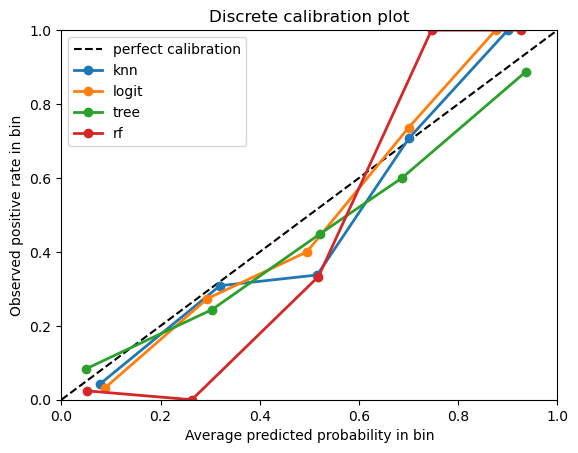

In [16]:
fig, ax = plt.subplots()
ax.plot([0, 1], [0, 1], linestyle="--", color="black", label="perfect calibration")

for model, table in calibration_compare.groupby("model", sort=False):
    ax.plot(table["mean_pred"], table["observed_rate"], marker="o", linewidth=2, label=model)

ax.set(
    xlabel="Average predicted probability in bin",
    ylabel="Observed positive rate in bin",
    title="Discrete calibration plot",
    xlim=(0, 1),
    ylim=(0, 1),
)
ax.legend()
plt.show()

In [17]:
calibration_compare.round(3)

,bin,n,mean_pred,observed_rate,model
0,"(-0.001, 0.2]",138,0.079,0.043,knn
1,"(0.2, 0.4]",94,0.320,0.309,knn
2,"(0.4, 0.6]",80,0.516,0.338,knn
3,"(0.6, 0.8]",65,0.701,0.708,knn
4,"(0.8, 1.0]",23,0.900,1.000,knn
5,"(-0.001, 0.2]",152,0.089,0.033,logit
6,"(0.2, 0.4]",95,0.294,0.274,logit
7,"(0.4, 0.6]",65,0.495,0.400,logit
8,"(0.6, 0.8]",53,0.700,0.736,logit
9,"(0.8, 1.0]",35,0.875,1.000,logit


## Reading the Calibration Plot
- Points close to the 45-degree line are good
- If the curve sits **below** the line, the model is overconfident
- If the curve sits **above** the line, the model is underconfident
- This is a very intuitive check when probabilities themselves matter
- Examples:
    - medical triage
    - credit default risk
    - admissions or retention scores
- If the situation matters --- high risk, low risk --- understanding the under- or over-confidence of the model matters

## Important Distinction
- A model can classify fairly well and still be poorly calibrated
- A model can also be well calibrated but not especially sharp at separating the classes
- So calibration and discrimination are related, but they are not the same thing

## Conclusion
- Confusion-matrix metrics answer: "How good are the hard class predictions at a chosen threshold?"
- Calibration answers: "Can I trust the predicted probabilities?"
- ROC/AUC answers: "How well does the model separate positives from negatives across many thresholds?"
- In practice:
    - start with the confusion matrix
    - check calibration if probabilities matter
    - use ROC/AUC when threshold choice is still open